In [47]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from matplotlib.ticker import FuncFormatter, MaxNLocator
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score

sys.path.insert(0, "src")
from profiles import Profile, profiles_to_df
from labels import (
    AGE_GROUP_LABELS,
    INCOME_LABELS,
    COMMUTE_FREQ_LABELS,
    SCHOOL_FREQ_LABELS,
    TELECOMMUTE_DAYS_LABELS,
)

##### Load filtered profiles

In [48]:
with open("artifacts/filtered_profiles.json", "r") as file:
    profiles = [Profile.model_validate(profile_json) for profile_json in json.load(file)]

print(f"Number of profiles: {len(profiles)}")

Number of profiles: 2262


##### Build person-level dataframe

In [49]:
df = profiles_to_df(profiles)
print(f"Rows: {len(df)}, Cols: {len(df.columns)}")

Rows: 2262, Cols: 36


##### Encode and scale features

In [50]:
feature_df = df.drop(columns = ["has_ev"])
categorical_cols = feature_df.select_dtypes(include = "object").columns.tolist()

numeric_cols = [col for col in feature_df.columns if col not in categorical_cols]
print(categorical_cols, numeric_cols)

encoder = OrdinalEncoder(handle_unknown = "use_encoded_value", unknown_value = -1, encoded_missing_value = -1)
encoded = encoder.fit_transform(feature_df[categorical_cols].astype(str))
numeric = feature_df[numeric_cols].fillna(-1.0).to_numpy()
feature_matrix = np.hstack([encoded, numeric])
scaled = StandardScaler().fit_transform(feature_matrix)
scaled_df = PCA(n_components = 15, random_state = 42).fit_transform(scaled)

print(f"Feature matrix shape: {scaled_df.shape}")
print(scaled_df)

['age_group', 'household_income', 'employment_status', 'student_status', 'workplace_ev_charging', 'workplace_loc', 'telecommute_days', 'commute_freq', 'school_freq', 'school_type', 'home_type', 'home_ownership', 'gender', 'race_ethnicity', 'dominant_dest_activity'] ['household_size', 'total_distance', 'num_trips', 'mean_arrival_Shopping', 'mean_arrival_Work', 'mean_arrival_Home', 'mean_arrival_Health care', 'mean_arrival_Meal', 'mean_arrival_Civic/Religious', 'mean_arrival_Exercise', 'mean_arrival_Drop off/pick up', 'mean_arrival_Non-shopping errand', 'mean_arrival_Recreation', 'mean_arrival_Gas', 'mean_arrival_Meal (quick-stop)', 'mean_arrival_Other', 'mean_arrival_Volunteer', 'mean_arrival_Socialize', 'mean_arrival_Entertainment', 'mean_arrival_School']
Feature matrix shape: (2262, 15)
[[-0.25802222 -0.46001715 -0.49702645 ...  0.11141915  0.43910839
  -0.41001607]
 [ 0.14173373 -0.4132313  -0.77374115 ... -0.24022145  1.9744943
   1.82637598]
 [ 0.28777338 -0.5166865  -1.6023215  ..

/var/folders/4w/3bqxxzqx2757wzv44nl1cm7r0000gn/T/ipykernel_71586/1759608254.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = feature_df.select_dtypes(include = "object").columns.tolist()


##### Remove outliers with iso forest

In [51]:
iso_forest = IsolationForest(contamination = 0.05, random_state = 42)
outlier_mask = iso_forest.fit_predict(scaled_df) == -1
print(f"Outliers removed: {outlier_mask.sum()}")

df = df[~outlier_mask].reset_index(drop = True)
scaled_df = scaled_df[~outlier_mask]

Outliers removed: 114


##### Visualize data with 2d umap

/Users/aryuh/Documents/ev_digital_city/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


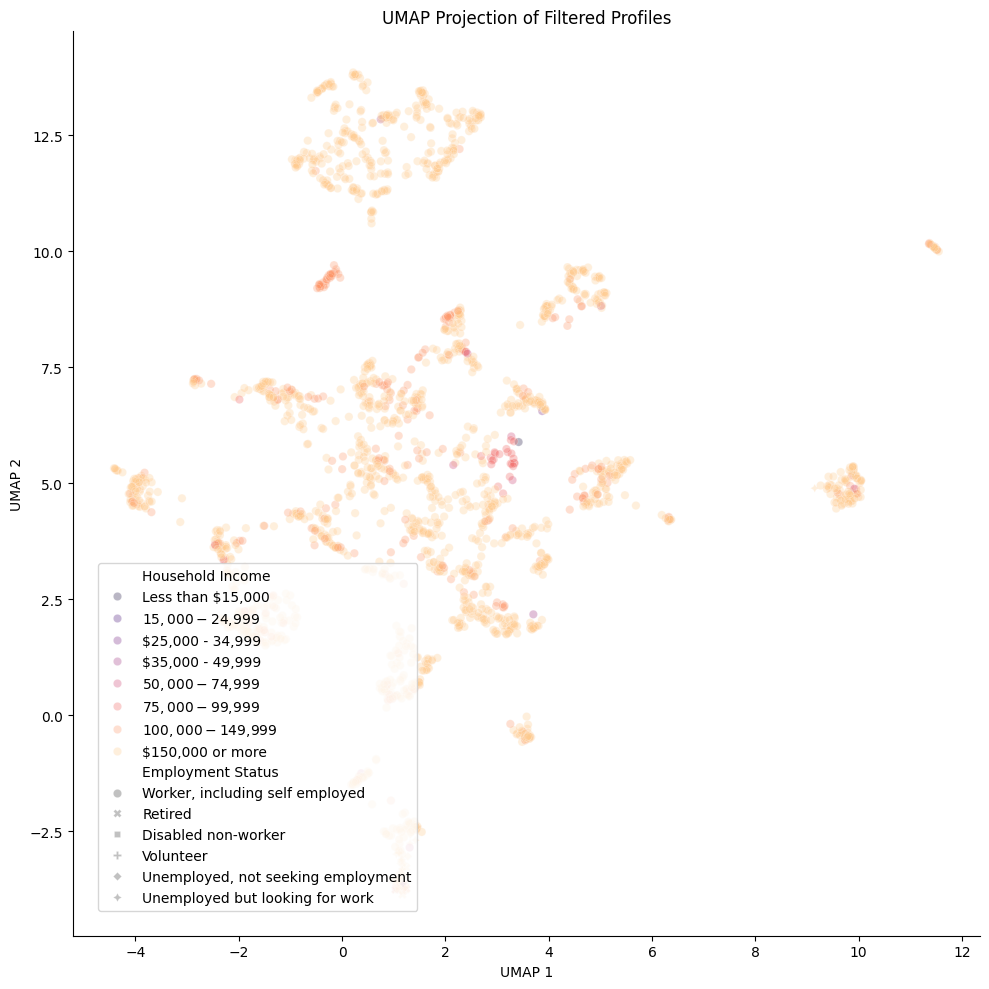

In [52]:
embedding = umap.UMAP(n_components = 2, random_state = 42).fit_transform(scaled_df)
umap_df = pd.DataFrame(embedding, columns = ["UMAP1", "UMAP2"])
umap_df["Household Income"] = df["household_income"].values
umap_df["Employment Status"] = df["employment_status"].values
income_order = [label for label in INCOME_LABELS.values() if label is not None]

plt.figure(figsize = (10, 10))
ax = sns.scatterplot(data = umap_df, x = "UMAP1", y = "UMAP2", hue = "Household Income", hue_order = income_order, style = "Employment Status", palette = "magma", alpha = 0.3)
plt.title("UMAP Projection of Filtered Profiles")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
ax.legend(loc = "lower left", bbox_to_anchor = (0.02, 0.02), frameon = True)
sns.despine()
plt.tight_layout()
plt.show()

##### Cluster data with k-means

Selected k = 4 (silhouette = 0.163)


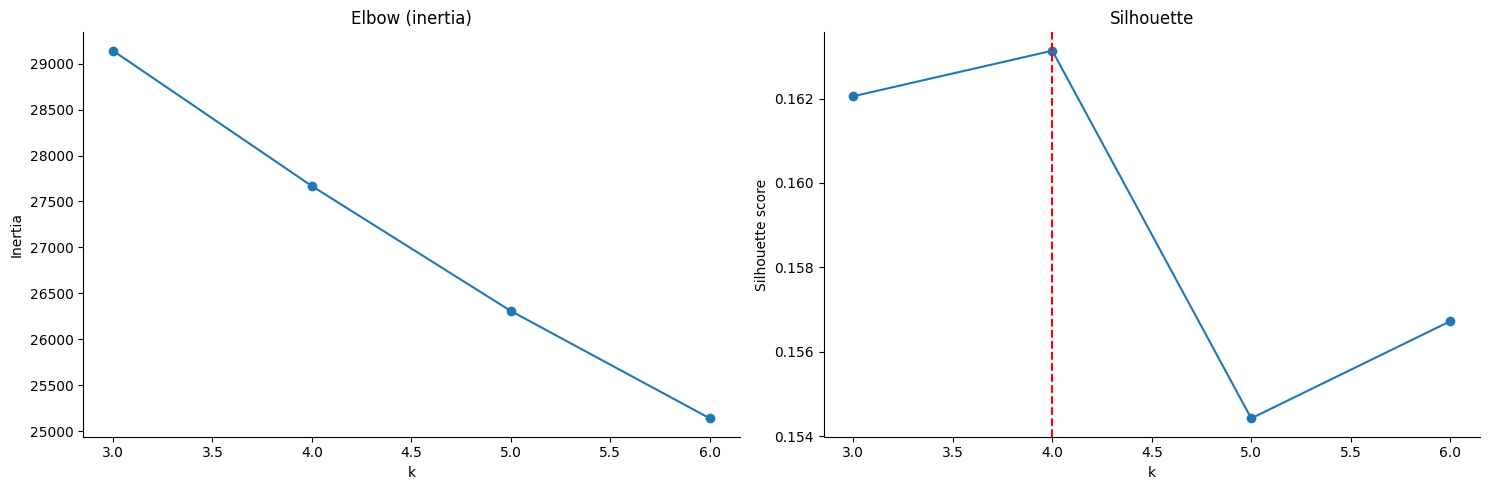

In [53]:
k_range = range(3, 7)
inertias = []
silhouettes = []
for k in k_range:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10).fit(scaled_df)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(scaled_df, km.labels_))

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"Selected k = {best_k} (silhouette = {max(silhouettes):.3f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 5))
ax1.plot(list(k_range), inertias, marker = "o")
ax1.set_title("Elbow (inertia)")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax2.plot(list(k_range), silhouettes, marker = "o")
ax2.axvline(best_k, color = "red", linestyle = "--")
ax2.set_title("Silhouette")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette score")
sns.despine()
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters = best_k, random_state = 42, n_init = 10)
clusters = kmeans.fit_predict(scaled_df)
umap_df["Cluster"] = clusters.astype(str)

##### Visualize clusters

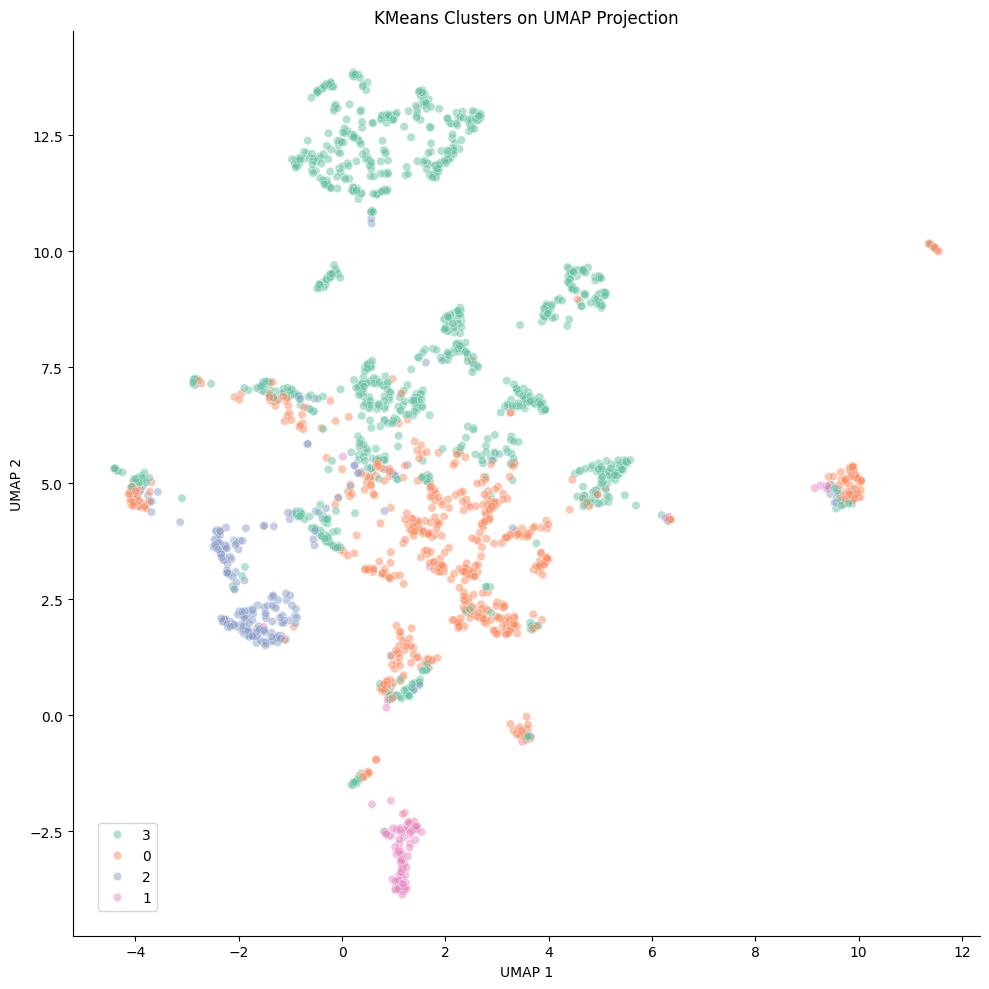

In [54]:
plt.figure(figsize = (10, 10))
ax = sns.scatterplot(data = umap_df, x = "UMAP1", y = "UMAP2", hue = "Cluster", palette = "Set2", alpha = 0.5)
plt.title("KMeans Clusters on UMAP Projection")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
ax.legend(loc = "lower left", bbox_to_anchor = (0.02, 0.02), frameon = True)
sns.despine()
plt.tight_layout()
plt.show()

##### Group data by cluster

In [55]:
cluster_dfs = [df[clusters == c].reset_index(drop = True) for c in range(best_k)]
for c, cluster_df in enumerate(cluster_dfs):
    print(f"Cluster {c}: {len(cluster_df)} persons")

Cluster 0: 661 persons
Cluster 1: 117 persons
Cluster 2: 228 persons
Cluster 3: 1142 persons


##### Graphs for each cluster

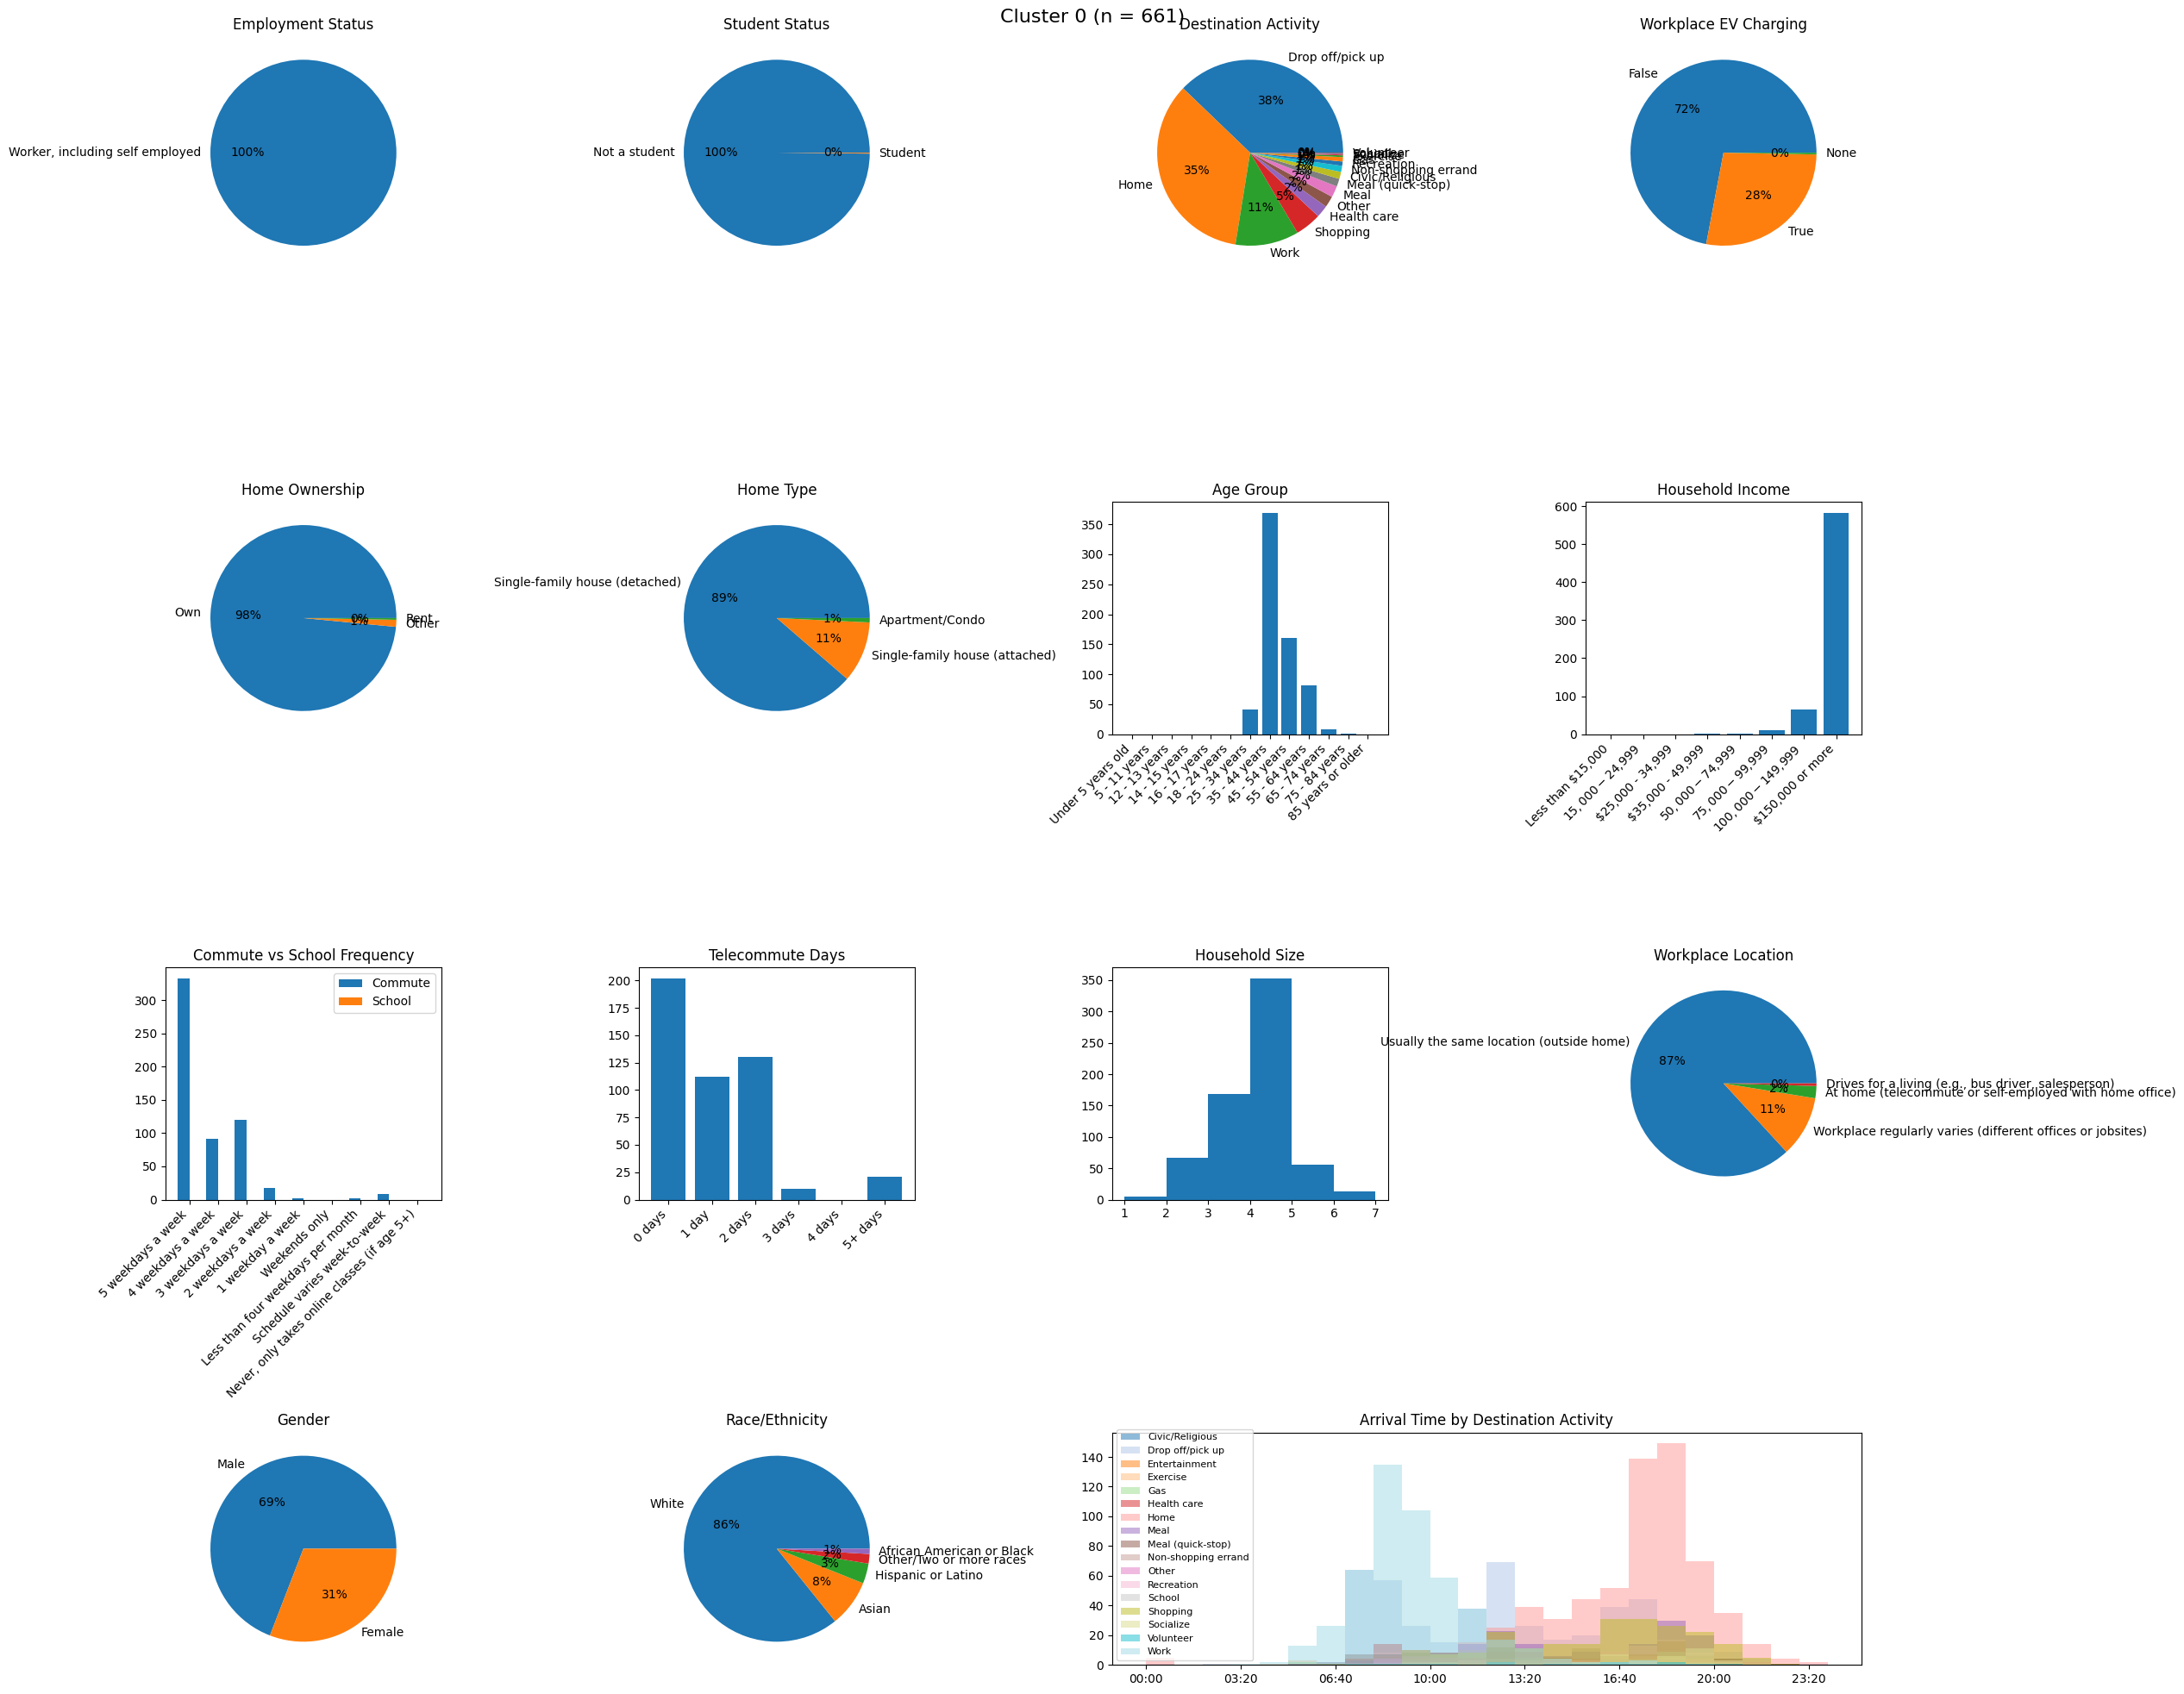

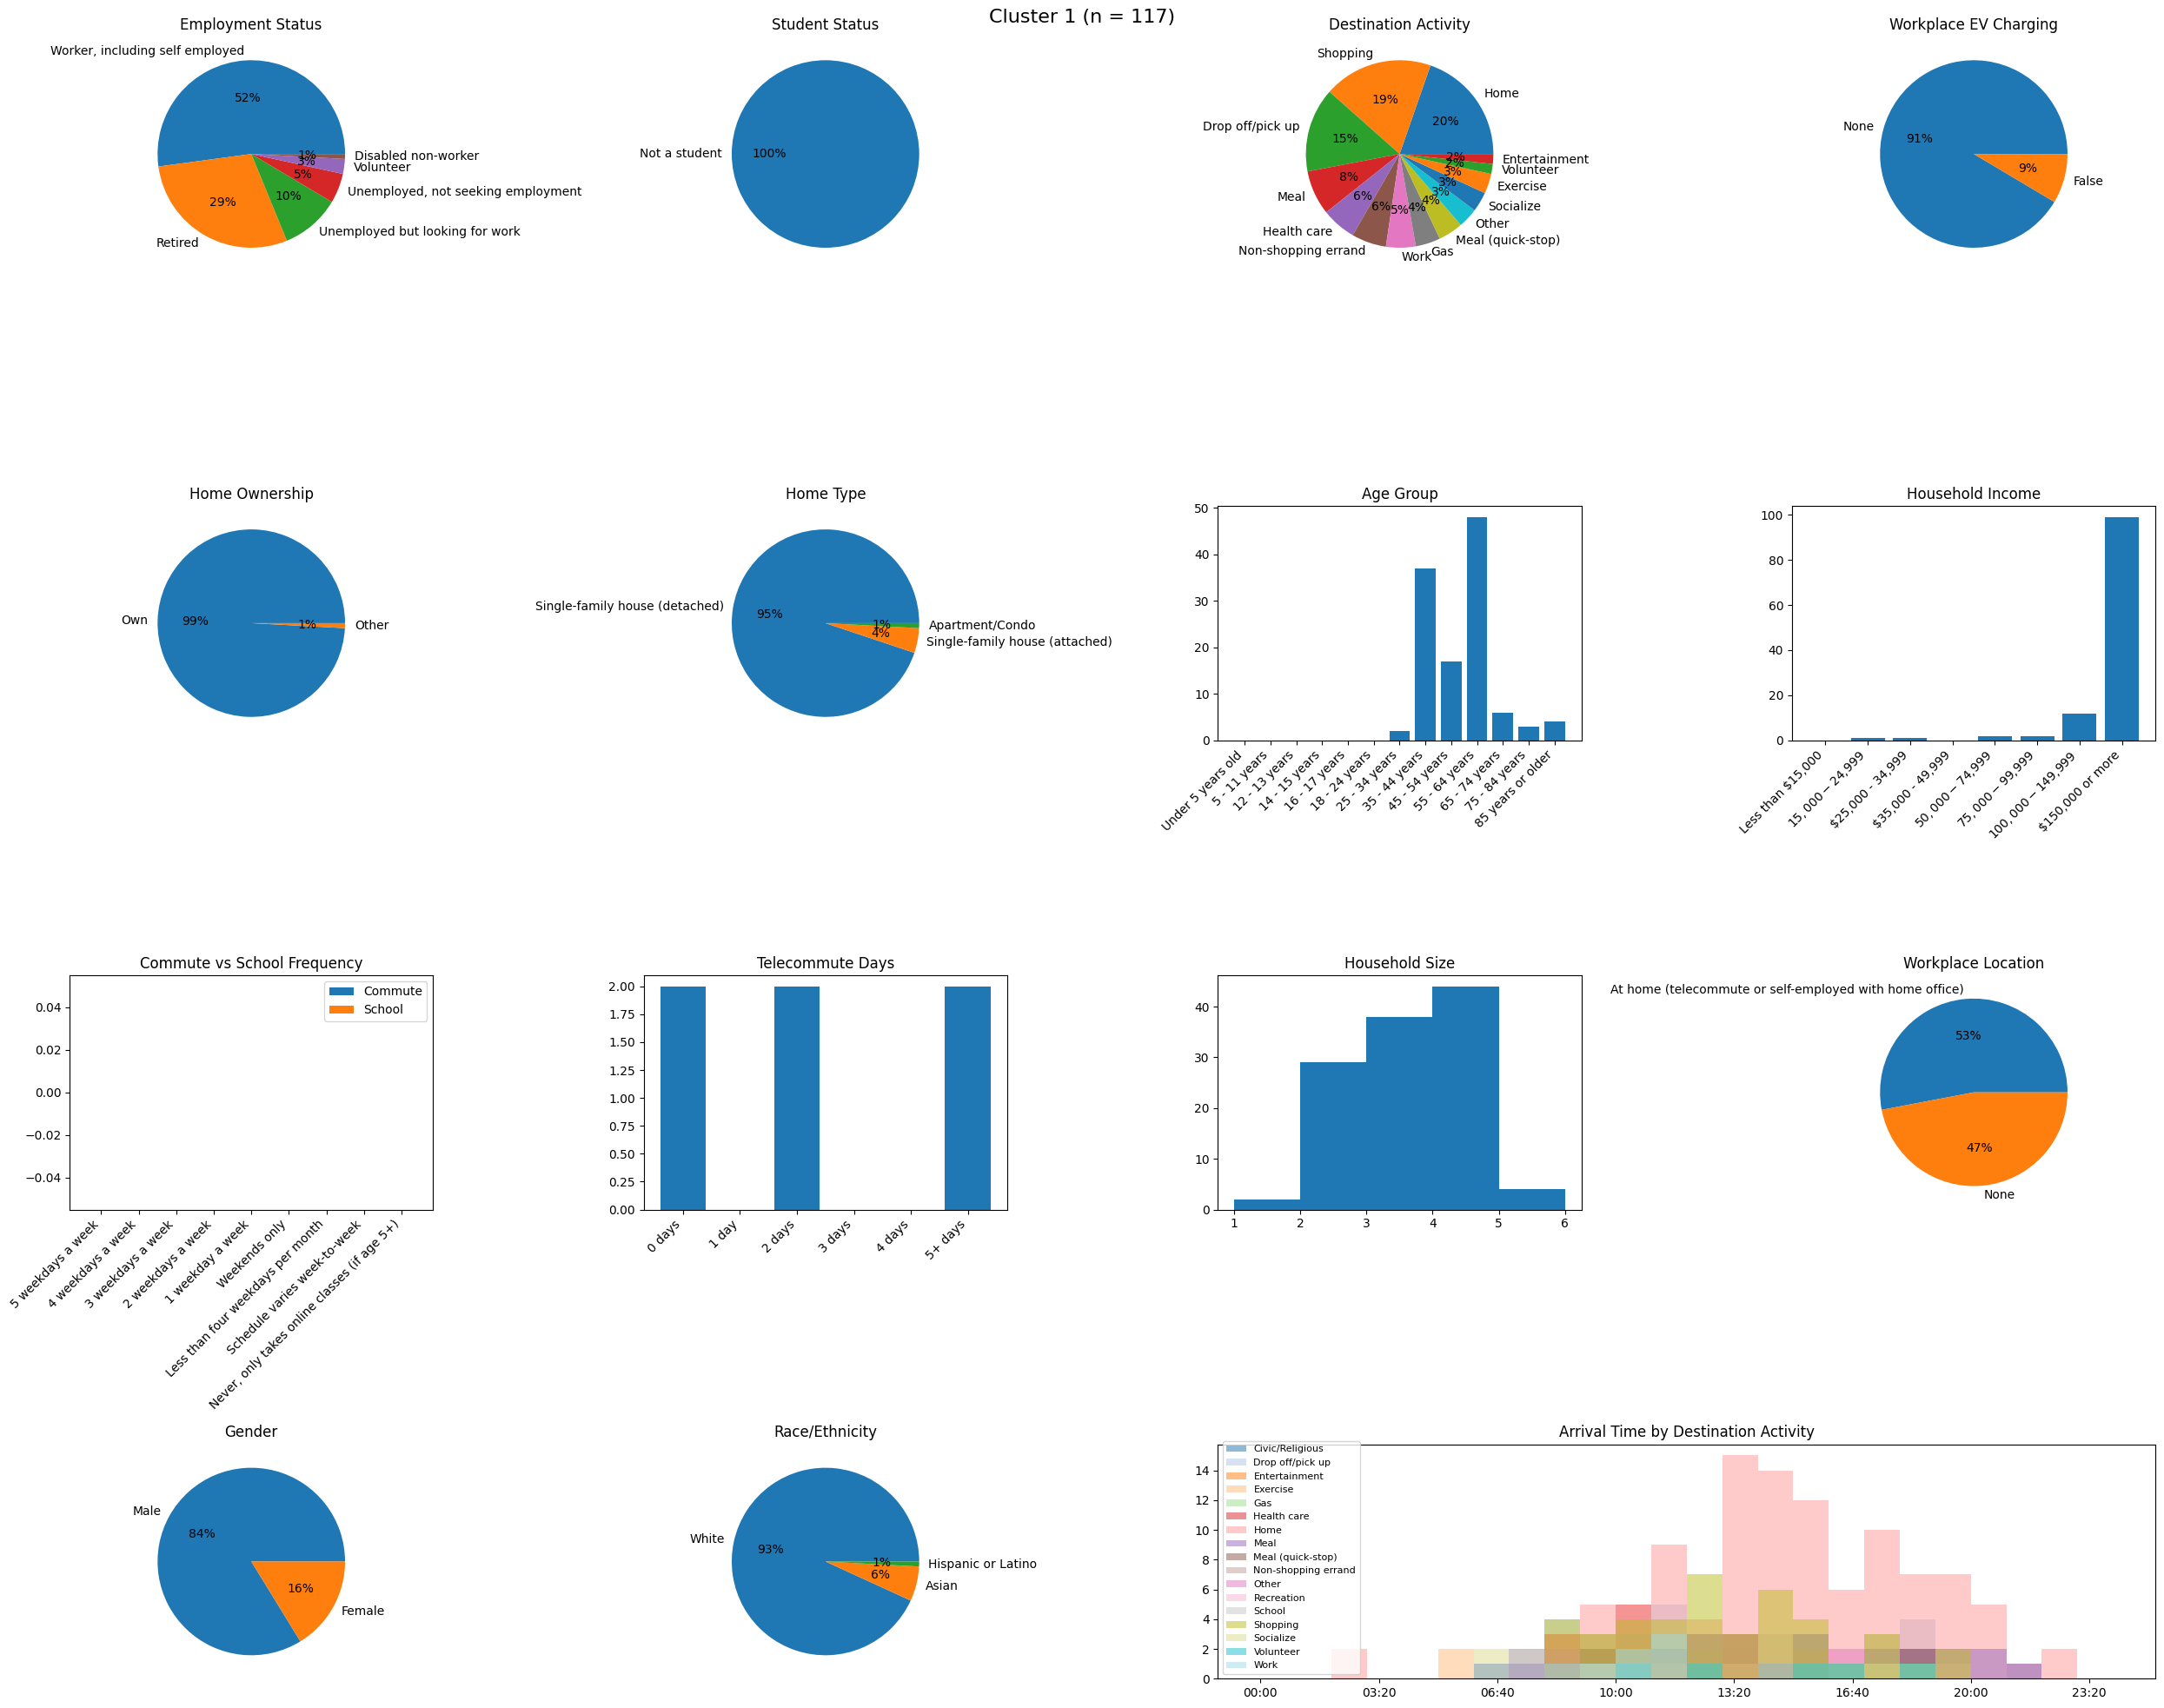

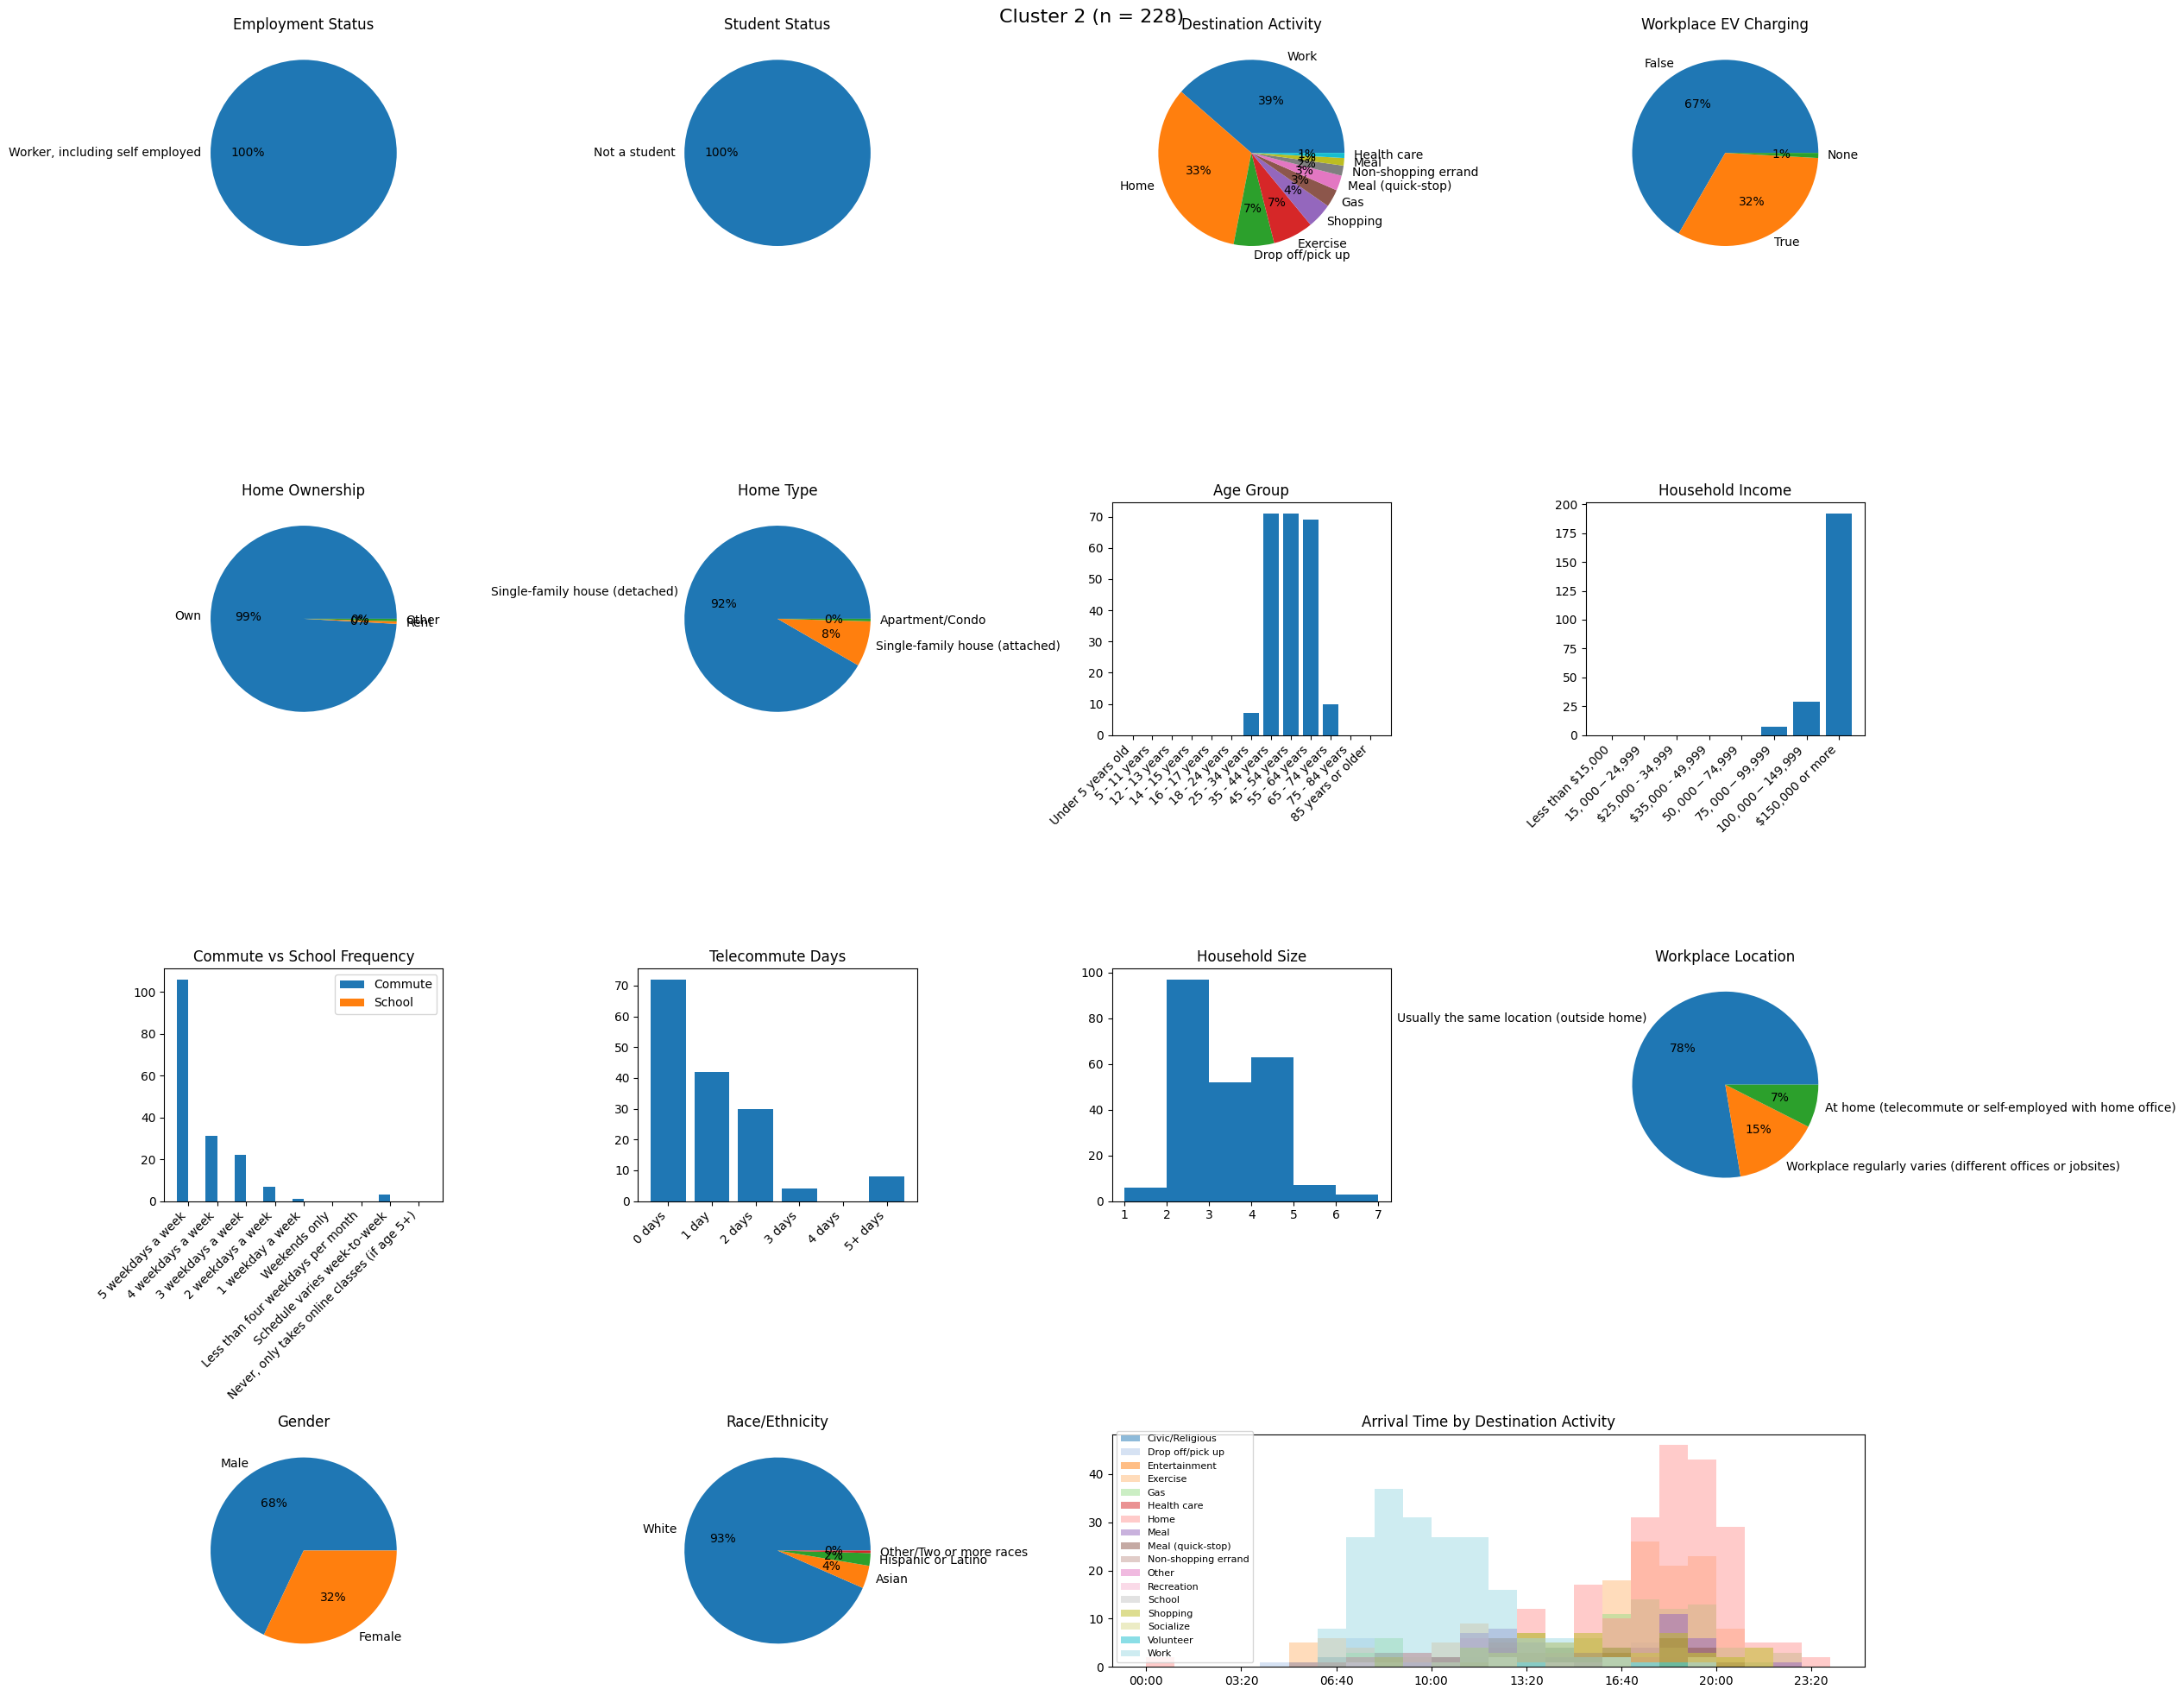

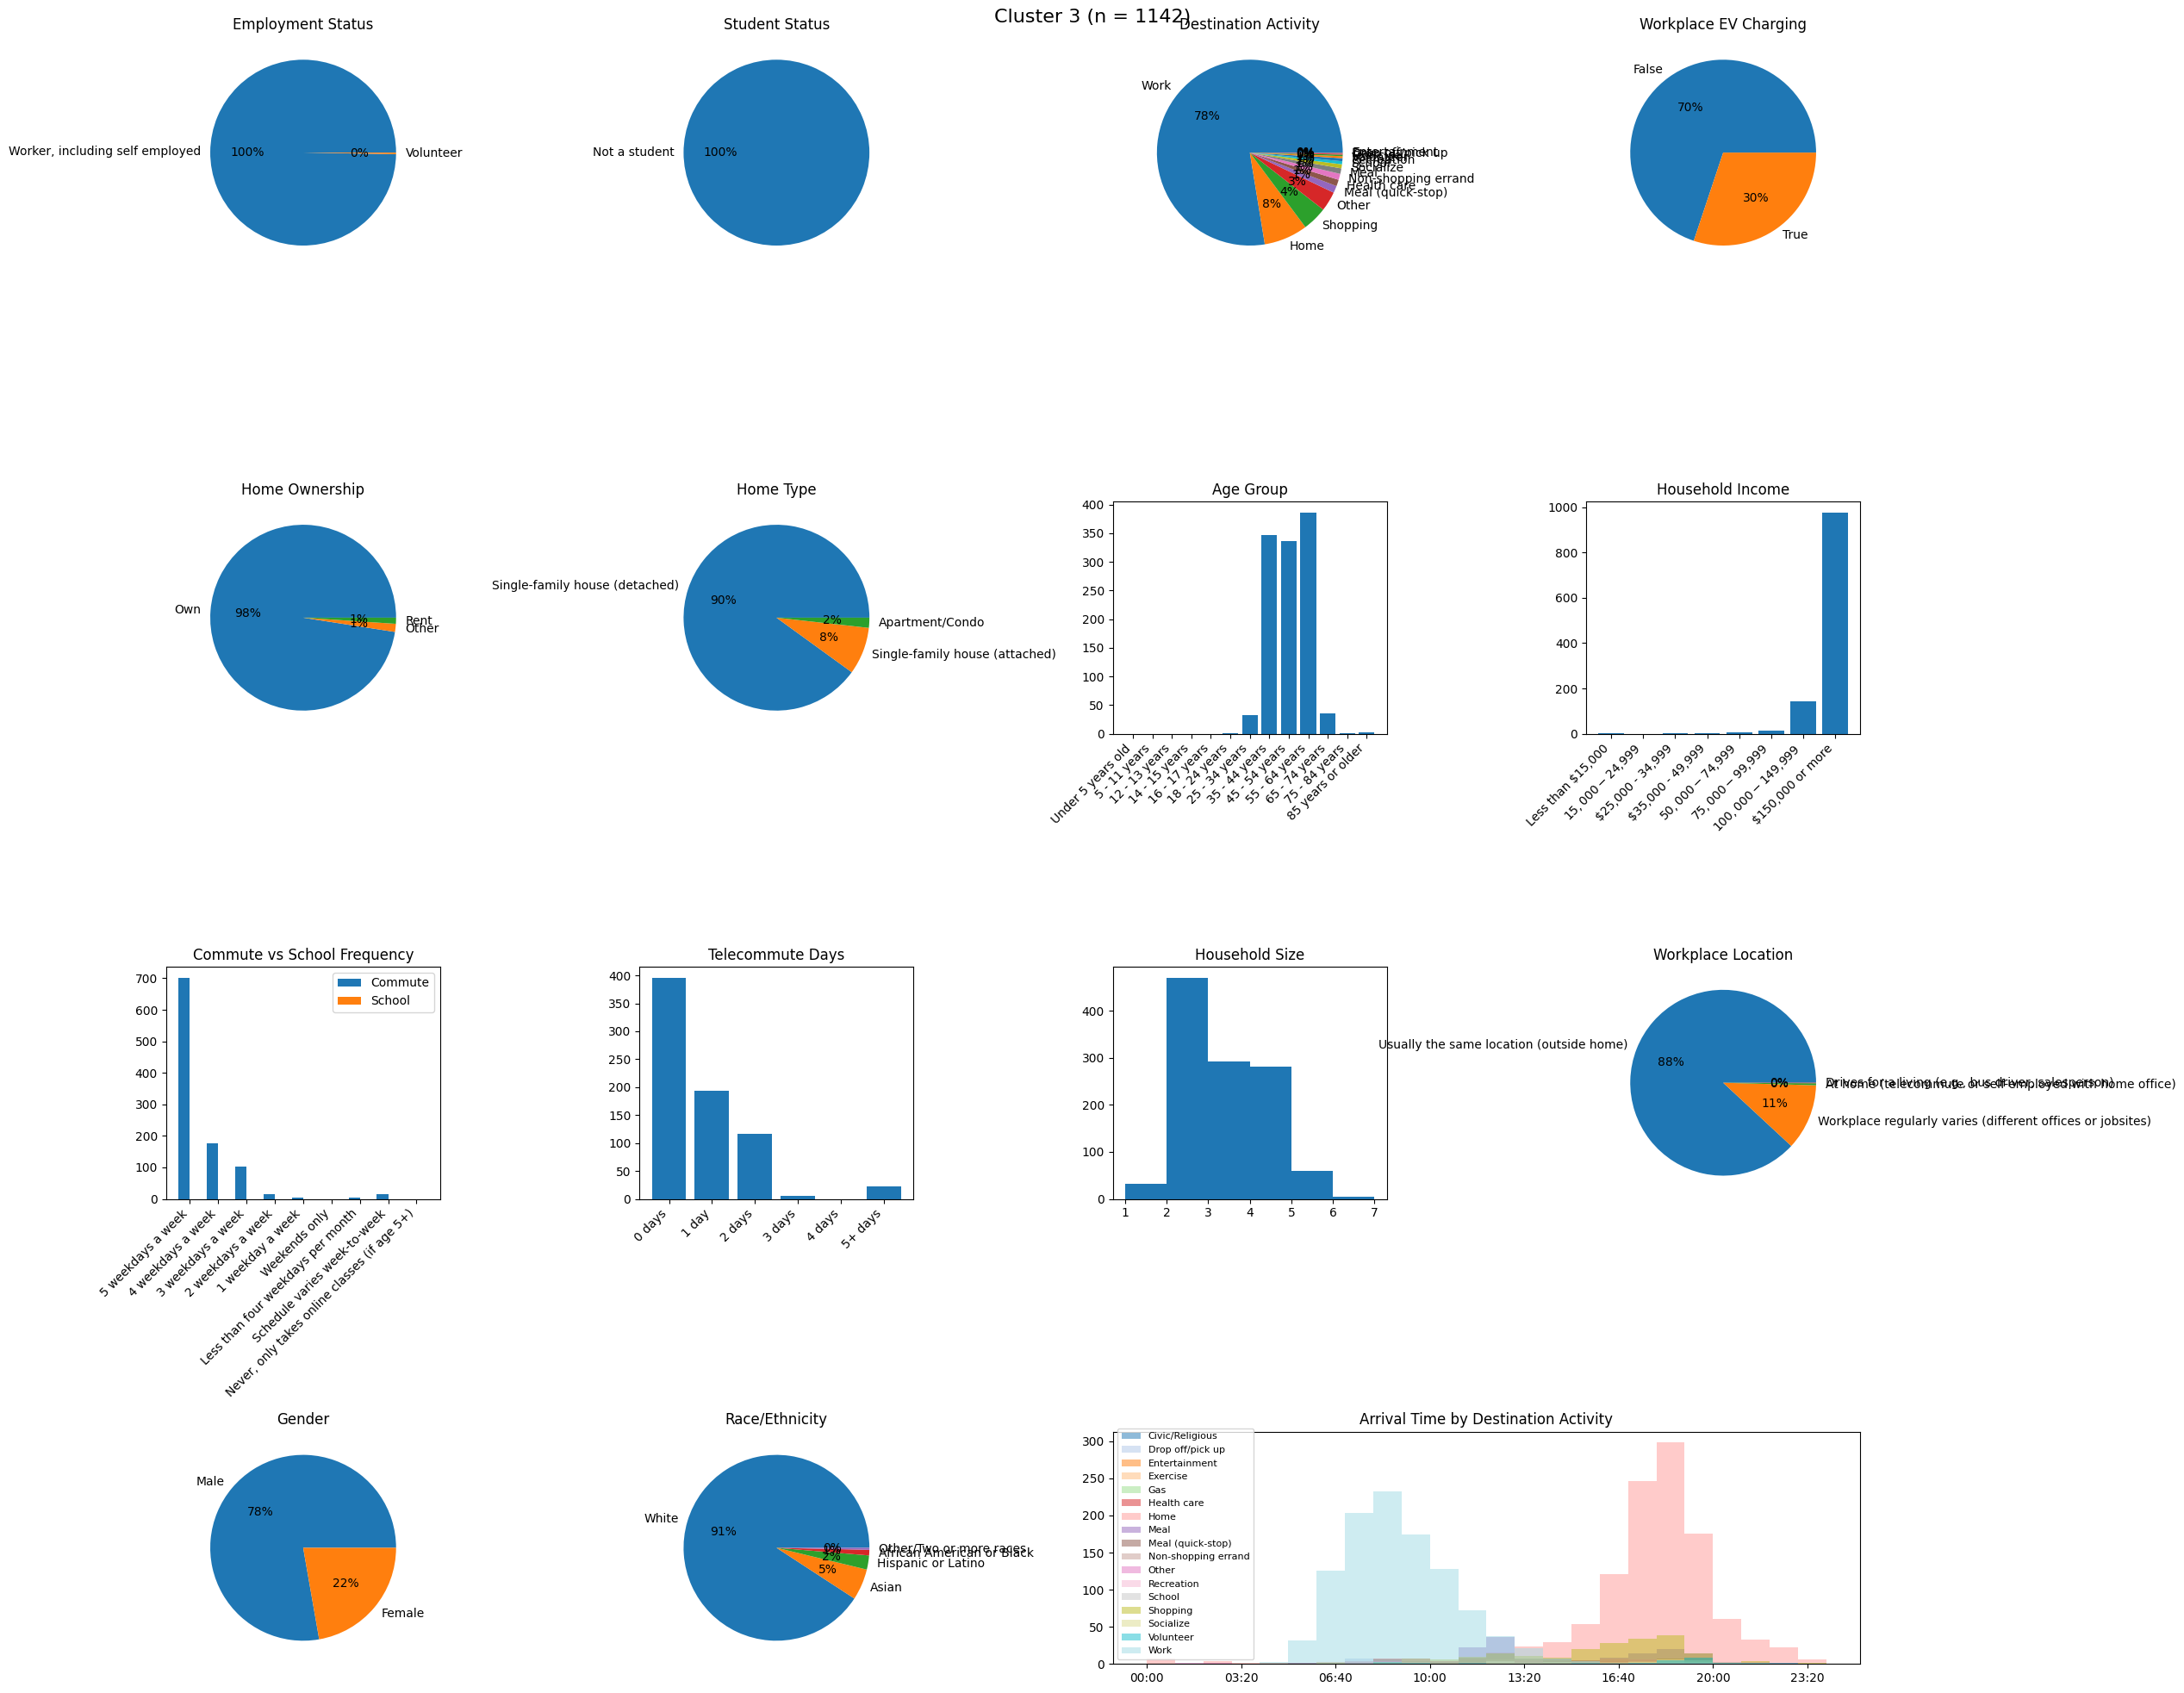

In [56]:
AGE_ORDER = [label for label in AGE_GROUP_LABELS.values() if label is not None]
INCOME_ORDER = [label for label in INCOME_LABELS.values() if label is not None]
COMMUTE_ORDER = [label for label in COMMUTE_FREQ_LABELS.values() if label is not None]
SCHOOL_ORDER = [label for label in SCHOOL_FREQ_LABELS.values() if label is not None]
FREQ_ORDER = list(dict.fromkeys(COMMUTE_ORDER + SCHOOL_ORDER))
TELECOMMUTE_ORDER = [label for label in TELECOMMUTE_DAYS_LABELS.values() if label is not None]


def pie(ax, series: pd.Series, title: str) -> None:
    counts = series.fillna("None").astype(str).value_counts()
    ax.pie(counts, labels = counts.index, autopct = "%1.0f%%")
    ax.set_title(title)


def ordered_bar(ax, series: pd.Series, order: list[str], title: str, rotation: int = 45) -> None:
    counts = series.fillna("None").astype(str).value_counts().reindex(order, fill_value = 0)
    ax.bar(np.arange(len(order)), counts.values)
    ax.set_xticks(np.arange(len(order)))
    ax.set_xticklabels(order, rotation = rotation, ha = "right")
    ax.set_title(title)


def grouped_freq_bar(ax, cluster_df: pd.DataFrame, title: str) -> None:
    commute_counts = cluster_df["commute_freq"].fillna("None").astype(str).value_counts().reindex(FREQ_ORDER, fill_value = 0)
    school_counts = cluster_df["school_freq"].fillna("None").astype(str).value_counts().reindex(FREQ_ORDER, fill_value = 0)
    x = np.arange(len(FREQ_ORDER))
    ax.bar(x - 0.2, commute_counts.values, width = 0.4, label = "Commute")
    ax.bar(x + 0.2, school_counts.values, width = 0.4, label = "School")
    ax.set_xticks(x)
    ax.set_xticklabels(FREQ_ORDER, rotation = 45, ha = "right")
    ax.set_title(title)
    ax.legend()


def arrival_time_by_activity_hist(ax, cluster_df: pd.DataFrame, title: str) -> None:
    per_activity_cols = sorted(col for col in cluster_df.columns if col.startswith("mean_arrival_") and col != "mean_arrival_minutes")
    cmap = plt.colormaps["tab20"].resampled(max(len(per_activity_cols), 1))
    bins = np.linspace(0, 1440, 25)
    for i, col in enumerate(per_activity_cols):
        values = cluster_df[col].dropna()
        activity = col.removeprefix("mean_arrival_")
        ax.hist(values, bins = bins, alpha = 0.5, label = activity, color = cmap(i))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda m, _: f"{int(m) // 60:02d}:{int(m) % 60:02d}"))
    ax.set_title(title)
    ax.legend(fontsize = 8)


def graph_cluster(cluster_df: pd.DataFrame, title_prefix: str) -> None:
    fig, axes = plt.subplots(4, 4, figsize = (25, 20))
    fig.suptitle(f"{title_prefix} (n = {len(cluster_df)})", fontsize = 16)

    pie(axes[0, 0], cluster_df["employment_status"], "Employment Status")
    pie(axes[0, 1], cluster_df["student_status"], "Student Status")
    pie(axes[0, 2], cluster_df["dominant_dest_activity"], "Destination Activity")
    pie(axes[0, 3], cluster_df["workplace_ev_charging"], "Workplace EV Charging")

    pie(axes[1, 0], cluster_df["home_ownership"], "Home Ownership")
    pie(axes[1, 1], cluster_df["home_type"], "Home Type")
    ordered_bar(axes[1, 2], cluster_df["age_group"], AGE_ORDER, "Age Group")
    ordered_bar(axes[1, 3], cluster_df["household_income"], INCOME_ORDER, "Household Income")

    grouped_freq_bar(axes[2, 0], cluster_df, "Commute vs School Frequency")
    ordered_bar(axes[2, 1], cluster_df["telecommute_days"], TELECOMMUTE_ORDER, "Telecommute Days")
    axes[2, 2].hist(cluster_df["household_size"].dropna(), bins = range(int(cluster_df["household_size"].min()), int(cluster_df["household_size"].max()) + 2))
    axes[2, 2].set_title("Household Size")
    pie(axes[2, 3], cluster_df["workplace_loc"], "Workplace Location")

    pie(axes[3, 0], cluster_df["gender"], "Gender")
    pie(axes[3, 1], cluster_df["race_ethnicity"], "Race/Ethnicity")
    gs = axes[3, 2].get_gridspec()
    axes[3, 2].remove()
    axes[3, 3].remove()
    arrival_ax = fig.add_subplot(gs[3, 2:4])
    arrival_time_by_activity_hist(arrival_ax, cluster_df, "Arrival Time by Destination Activity")

    plt.tight_layout()
    plt.show()


for cluster_id, cluster_df in enumerate(cluster_dfs):
    graph_cluster(cluster_df, f"Cluster {cluster_id}")

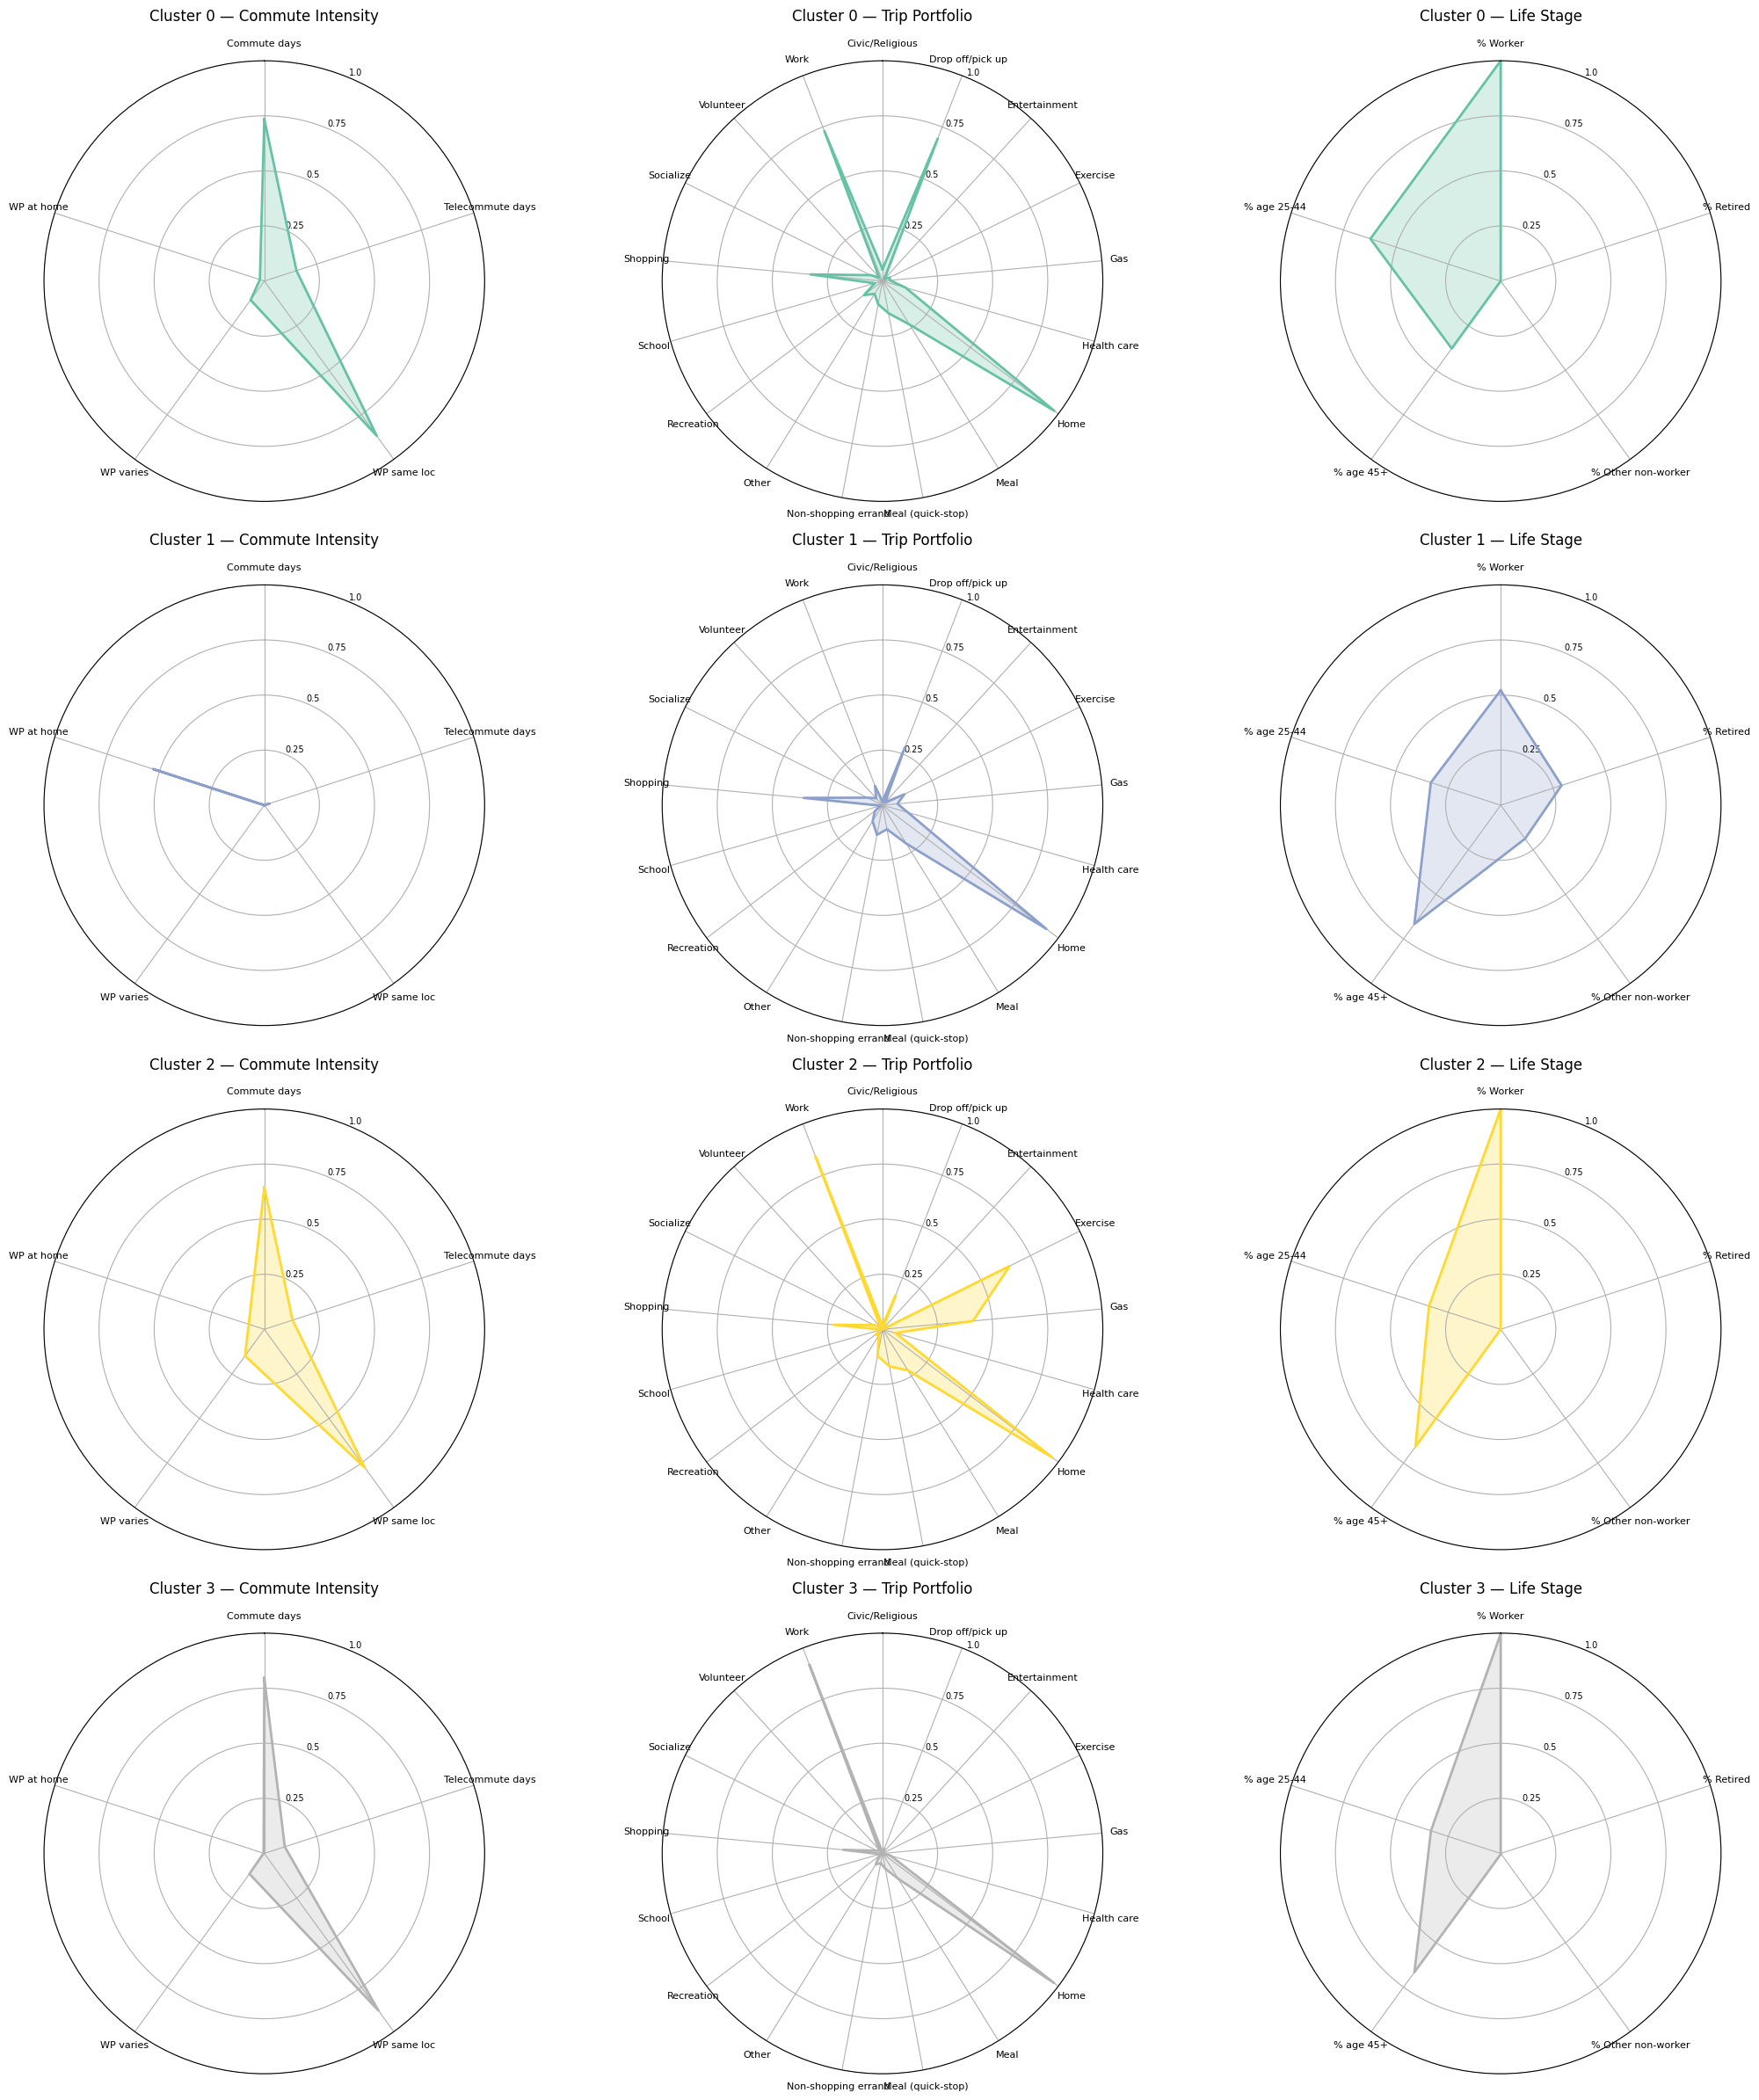

In [57]:
TELECOMMUTE_LABEL_TO_DAYS = {label: code for code, label in TELECOMMUTE_DAYS_LABELS.items() if label is not None and code >= 0}
COMMUTE_LABEL_TO_DAYS = {
    "5 weekdays a week": 5,
    "4 weekdays a week": 4,
    "3 weekdays a week": 3,
    "2 weekdays a week": 2,
    "1 weekday a week": 1,
    "Weekends only": 0,
    "Less than four weekdays per month": 0
}

COMMUTE_AXES = [
    "Commute days",
    "Telecommute days",
    "WP same loc",
    "WP varies",
    "WP at home"
]

WP_SAME = "Usually the same location (outside home)"
WP_VARIES = "Workplace regularly varies (different offices or jobsites)"
WP_HOME = "At home (telecommute or self-employed with home office)"

LIFE_STAGE_AXES = [
    "% Worker",
    "% Retired",
    "% Other non-worker",
    "% age 45+",
    "% age 25-44"
]

WORKER = "Worker, including self employed"
RETIRED = "Retired"
SENIOR_AGES = {"45 - 54 years", "55 - 64 years", "65 - 74 years", "75 - 84 years", "85 years or older"}
YOUNGER_AGES = {"25 - 34 years", "35 - 44 years"}


def commute_vector(cluster_df: pd.DataFrame) -> list[float]:
    if len(cluster_df) == 0:
        return [0.0] * len(COMMUTE_AXES)
    commute_freq = cluster_df["commute_freq"].astype(str)
    commute_days = commute_freq.map(COMMUTE_LABEL_TO_DAYS).fillna(0)
    workplace_loc = cluster_df["workplace_loc"].astype(str)
    telecommute_days = cluster_df["telecommute_days"].map(TELECOMMUTE_LABEL_TO_DAYS).fillna(0)
    return [
        float(commute_days.mean() / 5.0),
        float(telecommute_days.mean() / 5.0),
        float((workplace_loc == WP_SAME).mean()),
        float((workplace_loc == WP_VARIES).mean()),
        float((workplace_loc == WP_HOME).mean())
    ]


def life_stage_vector(cluster_df: pd.DataFrame) -> list[float]:
    if len(cluster_df) == 0:
        return [0.0] * len(LIFE_STAGE_AXES)
    employment = cluster_df["employment_status"].astype(str)
    age_group = cluster_df["age_group"].astype(str)
    worker_share = float((employment == WORKER).mean())
    retired_share = float((employment == RETIRED).mean())
    return [
        worker_share,
        retired_share,
        float(1.0 - worker_share - retired_share),
        float(age_group.isin(SENIOR_AGES).mean()),
        float(age_group.isin(YOUNGER_AGES).mean())
    ]


def radar(ax, axis_labels: list[str], values: list[float], title: str, color) -> None:
    angles = np.linspace(0, 2 * np.pi, len(axis_labels), endpoint = False).tolist()
    angles += angles[:1]
    loop = list(values) + [values[0]]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(axis_labels, fontsize = 8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize = 7)
    ax.plot(angles, loop, color = color, linewidth = 2)
    ax.fill(angles, loop, color = color, alpha = 0.25)
    ax.set_title(title, pad = 15)


activities = sorted({col.removeprefix("mean_arrival_") for cluster_df in cluster_dfs for col in cluster_df.columns if col.startswith("mean_arrival_") and col != "mean_arrival_minutes"})
cmap = plt.colormaps["Set2"].resampled(max(best_k, 1))

fig, axes = plt.subplots(best_k, 3, figsize = (21, 6 * best_k), subplot_kw = {"projection": "polar"})
if best_k == 1:
    axes = np.array([axes])

for cluster_id, cluster_df in enumerate(cluster_dfs):
    color = cmap(cluster_id)
    radar(axes[cluster_id, 0], COMMUTE_AXES, commute_vector(cluster_df), f"Cluster {cluster_id} — Commute Intensity", color)
    portfolio = [float(cluster_df[f"mean_arrival_{activity}"].notna().mean()) if f"mean_arrival_{activity}" in cluster_df.columns else 0.0 for activity in activities]
    radar(axes[cluster_id, 1], activities, portfolio, f"Cluster {cluster_id} — Trip Portfolio", color)
    radar(axes[cluster_id, 2], LIFE_STAGE_AXES, life_stage_vector(cluster_df), f"Cluster {cluster_id} — Life Stage", color)

plt.tight_layout()
plt.show()